# SpectralKappa: Upper-End Correction Experiments

**Idea**: Design $p_0$ on $[\lambda_{\min}, \lambda_{\rm upper}]$ where
$\lambda_{\rm upper} \ll \lambda_{\max} = 1$. Then use the minimax LP
to correct the $j$ eigenvalues **above** $\lambda_{\rm upper}$.

**Why this may work better than Mechanism 2**:
Correction targets are $1/\lambda_k = O(1)$ for large $\lambda_k$,
not $O(\kappa)$ as in the lower-end case. The correction $\Delta\mathbf{c}$
should remain small, so $\tau$ is less likely to blow up.

**Degree reduction**: $d_{\rm eff}$ is governed by
$\kappa_{\rm eff} = \lambda_{\rm upper}/\lambda_{\min} \ll \kappa$.

**Feasibility condition**: $n_0 = (d_{\rm eff}+1)/2 \geq j$ — unlike
Mechanism 2, here reducing $d$ and increasing $j$ are NOT in direct
conflict if $\lambda_{\rm upper}$ is chosen carefully.

**References**
- `Chapter18.tex` — QSVT degree $d = O(\sqrt{\kappa}\log 1/\varepsilon)$
- `SpectralCorrection.tex` — Gram-system spectral correction
- `MinimaxCorrection.py` — minimax $\tau$-controlled correction


## 0. Imports and Shared Utilities

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from MinimaxCorrection import MinimaxCorrection, effective_kappa
from PolynomialApproximators import MangPolynomial, spectral_correction
from PoissonFunctions import eigs_1d_poisson, eigs_2d_poisson

plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})


def normalize_eigs(lams_raw):
    """Normalize raw FD eigenvalues to (0, 1]. Returns (lams_norm, lam_max)."""
    lam_max = lams_raw.max()
    return np.sort(lams_raw / lam_max), lam_max


def build_base_poly(d, lambda_min, poly_class=MangPolynomial):
    """
    Build base polynomial of degree d on [lambda_min, 1].

    For the upper-end approach, d is chosen LOWER than mindegree for
    full-interval accuracy.  The polynomial is accurate near lambda_min
    but inaccurate above lambda_upper — those eigenvalues are corrected
    by the minimax LP.

    Parameters
    ----------
    d           : int   odd degree (must satisfy d >= 1)
    lambda_min  : float smallest normalized eigenvalue (= a in PolynomialApproximators)
    poly_class  : class MangPolynomial, RemezPolynomial, or SunderhaufPolynomial

    Returns
    -------
    Chebyshev polynomial object
    """
    if d % 2 == 0:
        d += 1   # enforce odd degree
    return poly_class.poly(d, lambda_min)


def find_lambda_upper(p0, lams_norm, eps_threshold=0.5):
    """
    Find the natural lambda_upper: the smallest eigenvalue where
    the compliance error |lambda * p0(lambda) - 1| exceeds eps_threshold.
    These are the eigenvalues that need correction.

    Returns
    -------
    idx_upper : indices of eigenvalues above the threshold
    lambda_upper : value of lams_norm[idx_upper[0]] (or 1.0 if none)
    """
    errors = np.abs(lams_norm * p0(lams_norm) - 1.0)
    idx_upper = np.where(errors > eps_threshold)[0]
    if len(idx_upper) == 0:
        return np.array([], dtype=int), 1.0
    return idx_upper, lams_norm[idx_upper[0]]


print('Imports OK')


Imports OK


## 1. Compliance Error Profile at Reduced Degree (1D Poisson)

Before running the LP, visualize how the compliance error
$|x\,p_0(x) - 1|$ distributes across eigenvalues as $d$ decreases
from $d_{\rm full}$ to $d_{\rm min}$. This identifies which eigenvalues
will need correction and gives an empirical picture of $\lambda_{\rm upper}$.


m=4, N=16, kappa=116.5, d_full=175


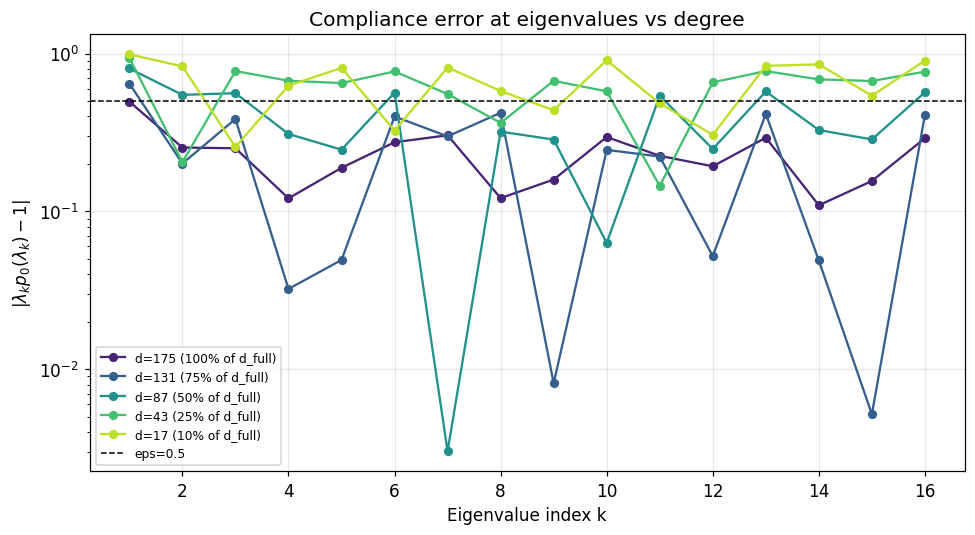

In [2]:
m         = 4
eps       = 0.5
lams_raw  = eigs_1d_poisson(m)
lams_norm, lam_max = normalize_eigs(lams_raw)
lambda_min = lams_norm[0]
kappa      = 1.0 / lambda_min
N          = len(lams_norm)

d_full = MangPolynomial.mindegree(eps, lambda_min)
print(f'm={m}, N={N}, kappa={kappa:.1f}, d_full={d_full}')

# Sweep degree fractions
fractions  = [1.0, 0.75, 0.5, 0.25, 0.1]
fig, ax    = plt.subplots(figsize=(9, 5))
colors     = plt.cm.viridis(np.linspace(0.1, 0.9, len(fractions)))

for frac, col in zip(fractions, colors):
    d_red = max(1, int(frac * d_full))
    if d_red % 2 == 0: d_red += 1
    p0    = build_base_poly(d_red, lambda_min)
    errs  = np.abs(lams_norm * p0(lams_norm) - 1.0)
    ax.semilogy(range(1, N+1), errs, 'o-', color=col, ms=5,
                label=f'd={d_red} ({frac:.0%} of d_full)')

ax.axhline(eps, color='k', ls='--', lw=1, label=f'eps={eps}')
ax.set_xlabel('Eigenvalue index k')
ax.set_ylabel(r'$|\lambda_k p_0(\lambda_k) - 1|$')
ax.set_title('Compliance error at eigenvalues vs degree')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_upper_compliance_profile.png', bbox_inches='tight')
plt.show()


## 2. Tau vs j — Upper-End Critical Test (1D Poisson)

At each $j$ (number of top eigenvalues to correct):
1. Set $d_{\rm eff}$ to the **minimum feasible** odd degree: $n_0 = (d+1)/2 \geq j$
   so $d_{\rm eff} = 2j - 1$
2. Build $p_0 = $ `MangPolynomial.poly(d_eff, lambda_min)`
3. Correct top $j$ eigenvalues with minimax LP
4. Record $\tau_{SC}$

Compare $\tau_{SC}$ to $\kappa$ (lower bound) and $\tau_0$ (base poly).


j= 1 | d=  1 | n0= 1 | tau_SC=      1.00 | tau_base=    1.99 | status=optimal
j= 2 | d=  3 | n0= 2 | tau_SC=      1.10 | tau_base=    3.04 | status=optimal
j= 3 | d=  5 | n0= 3 | tau_SC=      1.28 | tau_base=    4.38 | status=optimal
j= 4 | d=  7 | n0= 4 | tau_SC=      1.48 | tau_base=    5.74 | status=optimal
j= 5 | d=  9 | n0= 5 | tau_SC=      1.68 | tau_base=    7.09 | status=optimal
j= 6 | d= 11 | n0= 6 | tau_SC=      1.90 | tau_base=    8.43 | status=optimal
j= 7 | d= 13 | n0= 7 | tau_SC=      2.16 | tau_base=    9.75 | status=optimal
j= 8 | d= 15 | n0= 8 | tau_SC=      2.48 | tau_base=   11.06 | status=optimal

Infeasible: 0/8


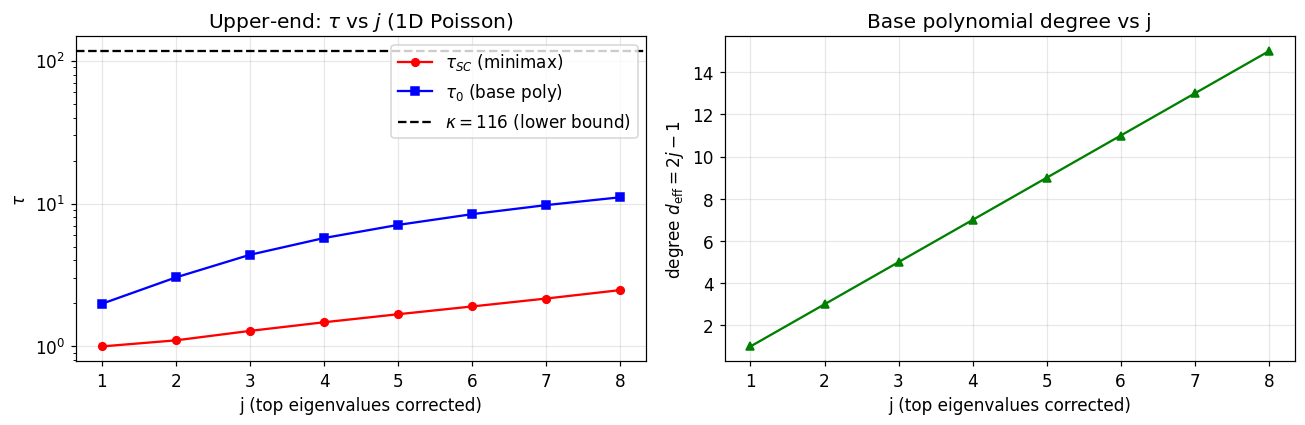

In [3]:
m          = 4
lams_raw   = eigs_1d_poisson(m)
lams_norm, lam_max = normalize_eigs(lams_raw)
lambda_min = lams_norm[0]
kappa      = 1.0 / lambda_min
N          = len(lams_norm)

# j = number of top eigenvalues to correct
# d_eff = 2j-1 (minimum odd degree with n0 = j >= j constraints)
j_values  = list(range(1, N // 2 + 1))
tau_sc    = []
tau_base  = []
degrees   = []
n_infeas  = 0

for j in j_values:
    d_eff      = 2 * j - 1                    # minimum feasible odd degree
    eigs_upper = lams_norm[N - j:]            # top j eigenvalues
    p0         = build_base_poly(d_eff, lambda_min)

    solver = MinimaxCorrection(p0, eigs_upper)
    result = solver.solve()

    tau_sc.append(result['tau'])
    tau_base.append(result['tau_base'])
    degrees.append(d_eff)
    if result['status'] not in ('optimal', 'optimal_inaccurate'):
        n_infeas += 1
    print(f'j={j:2d} | d={d_eff:3d} | n0={j:2d} | '
          f'tau_SC={result["tau"]:10.2f} | tau_base={result["tau_base"]:8.2f} | '
          f'status={result["status"]}')

print(f'\nInfeasible: {n_infeas}/{len(j_values)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].semilogy(j_values, tau_sc,   'r-o', ms=5, label=r'$\tau_{SC}$ (minimax)')
axes[0].semilogy(j_values, tau_base, 'b-s', ms=5, label=r'$\tau_0$ (base poly)')
axes[0].axhline(kappa, color='k', ls='--', label=fr'$\kappa={kappa:.0f}$ (lower bound)')
axes[0].set_xlabel('j (top eigenvalues corrected)')
axes[0].set_ylabel(r'$\tau$')
axes[0].set_title(r'Upper-end: $\tau$ vs $j$ (1D Poisson)')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(j_values, degrees, 'g-^', ms=5)
axes[1].set_xlabel('j (top eigenvalues corrected)')
axes[1].set_ylabel('degree $d_{\\rm eff} = 2j-1$')
axes[1].set_title('Base polynomial degree vs j')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('fig_upper_tau_vs_j.png', bbox_inches='tight')
plt.show()


## 3. Degree vs Tau Trade-off at Fixed j (1D Poisson)

Fix $j$ (number of top eigenvalues to correct) and vary $d$ from
$d_{\rm min} = 2j-1$ up to $d_{\rm full}$. This sweeps from minimum
feasible (tightest degree budget) to the full base polynomial.

Increasing $d$ gives the LP more freedom to control $\tau$.
This answers: how much extra degree is needed to bring $\tau$ near $\kappa$?


d=   7 | tau_SC=      1.48 | tau_base=    5.74 | status=optimal
d=   9 | tau_SC=      1.19 | tau_base=    7.09 | status=optimal
d=  11 | tau_SC=      1.14 | tau_base=    8.43 | status=optimal
d=  13 | tau_SC=      1.14 | tau_base=    9.75 | status=optimal_inaccurate
d=  15 | tau_SC=      1.14 | tau_base=   11.06 | status=optimal_inaccurate
d=  17 | tau_SC=      1.14 | tau_base=   12.36 | status=optimal_inaccurate


d:\Dropbox\Personal\suresh\Software\Github\ERSL-Private\QuantumResearch\SpectralKappa\MinimaxCorrection.py:244: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(verbose=verbose)


d=  19 | tau_SC=      1.14 | tau_base=   13.63 | status=optimal
d=  21 | tau_SC=      1.14 | tau_base=   14.90 | status=optimal_inaccurate
d=  23 | tau_SC=      1.14 | tau_base=   16.14 | status=optimal_inaccurate
d=  25 | tau_SC=      1.14 | tau_base=   17.37 | status=optimal
d=  27 | tau_SC=      1.14 | tau_base=   18.58 | status=optimal_inaccurate
d=  29 | tau_SC=      1.14 | tau_base=   19.77 | status=optimal
d=  31 | tau_SC=      1.14 | tau_base=   20.95 | status=optimal
d=  33 | tau_SC=      1.14 | tau_base=   22.11 | status=optimal
d=  35 | tau_SC=      1.14 | tau_base=   23.25 | status=optimal
d=  37 | tau_SC=      1.14 | tau_base=   24.38 | status=optimal
d=  39 | tau_SC=      1.14 | tau_base=   25.49 | status=optimal
d=  41 | tau_SC=      1.14 | tau_base=   26.59 | status=optimal
d=  43 | tau_SC=      1.14 | tau_base=   27.67 | status=optimal
d=  45 | tau_SC=      1.14 | tau_base=   28.73 | status=optimal
d=  47 | tau_SC=      1.14 | tau_base=   29.79 | status=optimal
d=  49 

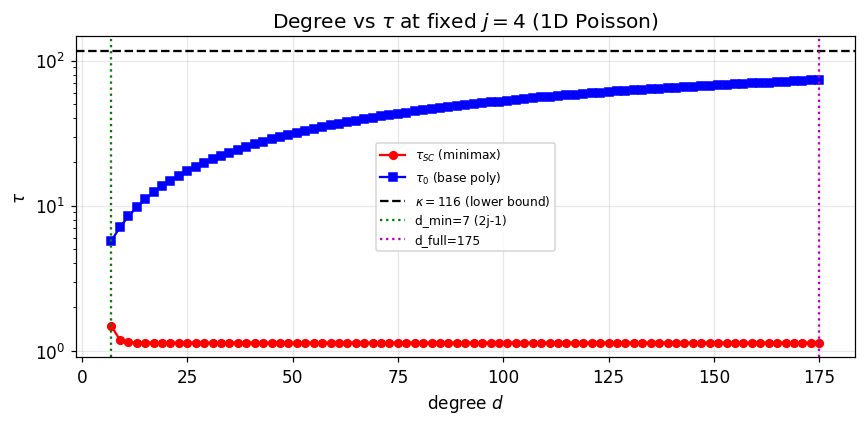

In [4]:
m          = 4
j          = 4                             # fix: correct top j eigenvalues
eps        = 0.5
lams_raw   = eigs_1d_poisson(m)
lams_norm, lam_max = normalize_eigs(lams_raw)
lambda_min = lams_norm[0]
kappa      = 1.0 / lambda_min
N          = len(lams_norm)

eigs_upper = lams_norm[N - j:]            # top j eigenvalues to correct
d_min      = 2 * j - 1                    # minimum feasible
d_full     = MangPolynomial.mindegree(eps, lambda_min)

# Sweep d from d_min to d_full (odd values only)
d_sweep   = list(range(d_min, d_full + 2, 2))
tau_sc_d  = []
tau_b_d   = []

for d in d_sweep:
    p0     = build_base_poly(d, lambda_min)
    solver = MinimaxCorrection(p0, eigs_upper)
    result = solver.solve()
    tau_sc_d.append(result['tau'])
    tau_b_d.append(result['tau_base'])
    print(f'd={d:4d} | tau_SC={result["tau"]:10.2f} | '
          f'tau_base={result["tau_base"]:8.2f} | status={result["status"]}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(d_sweep, tau_sc_d, 'r-o', ms=5, label=r'$\tau_{SC}$ (minimax)')
ax.semilogy(d_sweep, tau_b_d,  'b-s', ms=5, label=r'$\tau_0$ (base poly)')
ax.axhline(kappa, color='k', ls='--', label=fr'$\kappa={kappa:.0f}$ (lower bound)')
ax.axvline(d_min,  color='g', ls=':',  lw=1.5, label=f'd_min={d_min} (2j-1)')
ax.axvline(d_full, color='m', ls=':',  lw=1.5, label=f'd_full={d_full}')
ax.set_xlabel('degree $d$')
ax.set_ylabel(r'$\tau$')
ax.set_title(fr'Degree vs $\tau$ at fixed $j={j}$ (1D Poisson)')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'fig_upper_d_vs_tau_j{j}.png', bbox_inches='tight')
plt.show()


## 4. Polynomial Visualization (1D Poisson)

Inspect $p_0$ and $p_{SC}$ for a chosen $j$ and $d$.
Visually confirm that:
- $p_0$ is accurate near $\lambda_{\min}$ but drifts above $\lambda_{\rm upper}$
- $p_{SC}$ corrects the upper eigenvalues back to $1/\lambda_k$


kappa    = 116.46
tau_base = 5.737
tau_SC   = 1.477
residuals at corrected eigenvalues = [3.70814490e-14 1.28341782e-13 1.81854531e-13 8.57092175e-14]


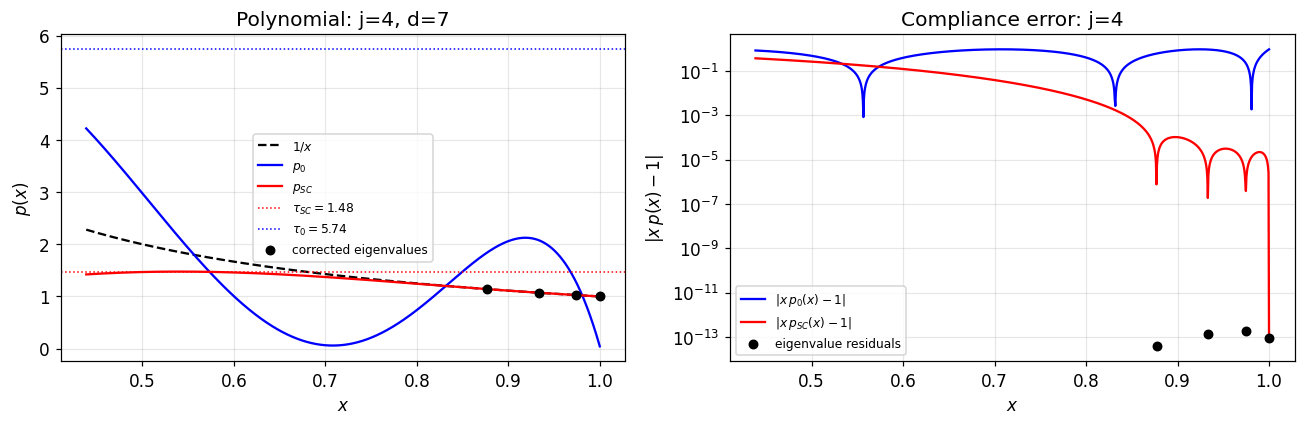

In [5]:
m          = 4
j          = 4
eps        = 0.5
lams_raw   = eigs_1d_poisson(m)
lams_norm, lam_max = normalize_eigs(lams_raw)
lambda_min = lams_norm[0]
kappa      = 1.0 / lambda_min
N          = len(lams_norm)

eigs_upper = lams_norm[N - j:]
d_eff      = 2 * j - 1
p0         = build_base_poly(d_eff, lambda_min)

solver = MinimaxCorrection(p0, eigs_upper)
result = solver.solve()

print(f'kappa    = {kappa:.2f}')
print(f'tau_base = {result["tau_base"]:.3f}')
print(f'tau_SC   = {result["tau"]:.3f}')
print(f'residuals at corrected eigenvalues = {result["residuals"]}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
solver.plot_polynomials(result, ax=axes[0])
axes[0].set_title(f'Polynomial: j={j}, d={d_eff}')
solver.plot_compliance_error(result, ax=axes[1])
axes[1].set_title(f'Compliance error: j={j}')
plt.tight_layout()
plt.savefig(f'fig_upper_poly_j{j}.png', bbox_inches='tight')
plt.show()


## 5. Upper-End vs Lower-End vs Standard (1D Poisson)

Side-by-side comparison at matched degree budgets.
For a fixed target degree $d^*$, compare:
1. **Standard Mang**: base on $[\lambda_{\min}, 1]$, no correction
2. **Lower-end (Mechanism 2)**: base on $[\lambda_{K+1}, 1]$, correct $K$ smallest
3. **Upper-end**: base on $[\lambda_{\min}, 1]$ at degree $d^*$, correct $j$ largest


In [6]:
m          = 4
eps        = 0.5
lams_raw   = eigs_1d_poisson(m)
lams_norm, lam_max = normalize_eigs(lams_raw)
lambda_min = lams_norm[0]
kappa      = 1.0 / lambda_min
N          = len(lams_norm)
d_full     = MangPolynomial.mindegree(eps, lambda_min)

# Choose a target degree budget d_star
d_star = max(3, d_full // 3)
if d_star % 2 == 0: d_star += 1
j_star = (d_star + 1) // 2          # max feasible j at degree d_star
print(f'd_full={d_full}, d_star={d_star}, j_star={j_star}')

results = []

# Method 1: Standard Mang at d_full (reference)
p0_full = MangPolynomial.poly(d_full, lambda_min)
errs_full = np.abs(lams_norm * p0_full(lams_norm) - 1.0)
tau_full  = np.max(np.abs(p0_full(np.linspace(-1,1,5000))))
results.append({'Method': f'Standard Mang (d={d_full})',
                'Degree': d_full, 'tau': tau_full,
                'max_compliance_err': errs_full.max()})

# Method 2: Standard Mang at d_star (no correction)
p0_star = MangPolynomial.poly(d_star, lambda_min)
errs_star = np.abs(lams_norm * p0_star(lams_norm) - 1.0)
tau_star  = np.max(np.abs(p0_star(np.linspace(-1,1,5000))))
results.append({'Method': f'Standard Mang (d={d_star}, no correction)',
                'Degree': d_star, 'tau': tau_star,
                'max_compliance_err': errs_star.max()})

# Method 3: Lower-end (Mechanism 2) at d_star
# Base on [lambda_{j_star+1}, 1], correct j_star smallest
a_lower = min(lams_norm[j_star], 1.0 - 1e-10)
d_lower = MangPolynomial.mindegree(eps, a_lower)
p0_lower = MangPolynomial.poly(d_lower, a_lower)
mm_lower = MinimaxCorrection(p0_lower, lams_norm[:j_star])
res_lower = mm_lower.solve()
errs_lower = np.abs(lams_norm * res_lower['p_SC'](lams_norm) - 1.0) if res_lower['p_SC'] is not None else None
results.append({'Method': f'Lower-end Mang (d={d_lower}, K={j_star})',
                'Degree': d_lower, 'tau': res_lower['tau'],
                'max_compliance_err': errs_lower.max() if errs_lower is not None else np.nan})

# Method 4: Upper-end at d_star
eigs_upper = lams_norm[N - j_star:]
p0_up      = build_base_poly(d_star, lambda_min)
mm_up      = MinimaxCorrection(p0_up, eigs_upper)
res_up     = mm_up.solve()
errs_up    = np.abs(lams_norm * res_up['p_SC'](lams_norm) - 1.0) if res_up['p_SC'] is not None else None
results.append({'Method': f'Upper-end Mang (d={d_star}, j={j_star})',
                'Degree': d_star, 'tau': res_up['tau'],
                'max_compliance_err': errs_up.max() if errs_up is not None else np.nan})

# Print table
print(f'{"Method":<45} {"Degree":>8} {"tau":>10} {"max |xp-1|":>12}')
print('-' * 80)
for r in results:
    print(f'{r["Method"]:<45} {r["Degree"]:>8d} '
          f'{r["tau"]:>10.2f} {r["max_compliance_err"]:>12.4e}')


d_full=175, d_star=59, j_star=30


IndexError: index 30 is out of bounds for axis 0 with size 16

## 6. 2D Poisson Extension

Repeat the $\tau$ vs $j$ sweep for 2D Poisson.
Degenerate eigenvalues are de-duplicated before correction.


In [ ]:
m          = 2              # N1=4, N=16 total nodes
lams_raw   = eigs_2d_poisson(m)
lams_norm, lam_max = normalize_eigs(lams_raw)
lambda_min = lams_norm[0]
kappa_2d   = 1.0 / lambda_min
N          = len(lams_norm)

# De-duplicate (relative gap > 0.1%)
lams_u = [lams_norm[0]]
for l in lams_norm[1:]:
    if (l - lams_u[-1]) / lams_u[-1] > 1e-3:
        lams_u.append(l)
lams_unique = np.array(lams_u)
Nu = len(lams_unique)
print(f'm={m}, N={N}, unique={Nu}, kappa={kappa_2d:.1f}')

j_values_2d = list(range(1, Nu // 2 + 1))
tau_sc_2d   = []
tau_base_2d = []

for j in j_values_2d:
    d_eff       = 2 * j - 1
    eigs_upper  = lams_unique[Nu - j:]
    p0          = build_base_poly(d_eff, lambda_min)
    solver      = MinimaxCorrection(p0, eigs_upper)
    result      = solver.solve()
    tau_sc_2d.append(result['tau'])
    tau_base_2d.append(result['tau_base'])
    print(f'j={j:2d} | d={d_eff:3d} | tau_SC={result["tau"]:10.2f} | '
          f'tau_base={result["tau_base"]:8.2f} | status={result["status"]}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(j_values_2d, tau_sc_2d,   'r-o', ms=5, label=r'$\tau_{SC}$ (minimax)')
ax.semilogy(j_values_2d, tau_base_2d, 'b-s', ms=5, label=r'$\tau_0$ (base poly)')
ax.axhline(kappa_2d, color='k', ls='--', label=fr'$\kappa={kappa_2d:.0f}$')
ax.set_xlabel('j (top unique eigenvalues corrected)')
ax.set_ylabel(r'$\tau$')
ax.set_title(r'2D Poisson: upper-end $\tau$ vs $j$')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('fig_upper_tau_vs_j_2d.png', bbox_inches='tight')
plt.show()


## 7. Summary

| Section | Experiment | Key question |
|---|---|---|
| 1 | Compliance error profile | Where does $p_0$ fail as $d$ decreases? |
| 2 | $\tau$ vs $j$ (1D) | **Critical test** — does upper-end control $\tau$? |
| 3 | $d$ vs $\tau$ at fixed $j$ | How much extra $d$ brings $\tau \to \kappa$? |
| 4 | Polynomial plot | Qualitative behavior of correction |
| 5 | Upper vs lower vs standard | Which strategy wins at matched degree? |
| 6 | 2D Poisson | Does result generalize? |

**Interpretation guide**:
- $\tau_{SC} \approx \kappa$: upper-end approach is viable; degree $d^*$ is the real cost
- $\tau_{SC} > \kappa$ but bounded: Tikhonov regularization may close the gap
- $\tau_{SC} \gg \kappa$ or infeasible: approach fails; classical preconditioning required
